## Exercise 5.5: Backdoor Attack on the Pedestrian Detector A backdoor attack poisons a fraction of the training data: a trigger pattern is added to selected images and their labels are flipped. After training, the model behaves normally on clean inputs but misclassifies whenever the trigger is present. 

In [3]:
# load train labels
from pathlib import Path
import pandas as pd
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

TRAIN_DIR = PROJECT_ROOT / "data" / "exercise_3_5" / "train"

print("Train folder exists:", TRAIN_DIR.exists())

train_csv = sorted(TRAIN_DIR.rglob("*.csv"))[0]
train_df = pd.read_csv(train_csv)

print("Train shape:", train_df.shape)
print("Columns:", train_df.columns.tolist())

display(train_df.head())

Train folder exists: True
Train shape: (7200, 7)
Columns: ['frame', 'has_traffic_light', 'has_pedestrian', 'has_vehicle', 'px_traffic_light', 'px_pedestrian', 'px_vehicle']


,frame,has_traffic_light,has_pedestrian,has_vehicle,px_traffic_light,px_pedestrian,px_vehicle
0,0,False,False,True,0,0,85
1,10,False,True,True,14,301,1138
2,20,True,True,True,99,196,517
3,30,True,True,True,99,181,530
4,40,True,True,True,101,169,538


In [4]:
# create image mapping
IMAGE_EXTENSIONS = ["*.png", "*.jpg", "*.jpeg"]

def find_images(folder):
    image_files = []
    for ext in IMAGE_EXTENSIONS:
        image_files.extend(folder.rglob(ext))
    return image_files

def build_frame_to_image_map(folder):
    image_files = find_images(folder)
    frame_to_image = {}

    for image_path in image_files:
        number = "".join([c for c in image_path.stem if c.isdigit()])
        if number != "":
            frame_to_image[int(number)] = image_path

    return frame_to_image

train_frame_to_image = build_frame_to_image_map(TRAIN_DIR)

print("Mapped training images:", len(train_frame_to_image))
print("First 5 frames:", list(train_frame_to_image.keys())[:5])

Mapped training images: 7200
First 5 frames: [66980, 31600, 63620, 35300, 67320]


In [ ]:
# 1. Implement a trigger function: overlay a small bright-coloured square (10 ×10 pixels, colour (255,0,0)) at a position of your choice in the image. 

# add red square trigger
from PIL import ImageDraw

def add_trigger(image, size=10, color=(255, 0, 0), position="bottom_right"):
    image = image.copy().convert("RGB")
    draw = ImageDraw.Draw(image)

    width, height = image.size
    margin = 5

    if position == "bottom_right":
        x0 = width - size - margin
        y0 = height - size - margin
    elif position == "top_right":
        x0 = width - size - margin
        y0 = margin
    elif position == "bottom_left":
        x0 = margin
        y0 = height - size - margin
    else:
        x0 = margin
        y0 = margin

    x1 = x0 + size
    y1 = y0 + size

    draw.rectangle([x0, y0, x1, y1], fill=color)

    return image

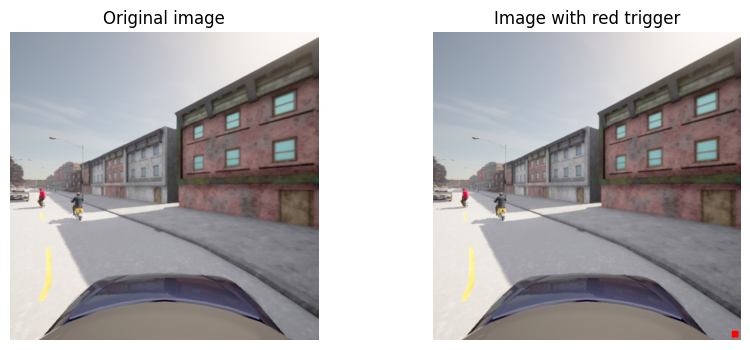

In [8]:
# test trigger function
sample_row = train_df[train_df["has_pedestrian"] == True].iloc[0]
sample_frame = int(sample_row["frame"])

image_path = train_frame_to_image[sample_frame]

clean_image = Image.open(image_path).convert("RGB")
triggered_image = add_trigger(clean_image)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(clean_image)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(triggered_image)
plt.title("Image with red trigger")
plt.axis("off")

plt.show()

In [9]:
# 2. Poison the training data: for p = 10% of images where pedestrian_present = True, apply the trigger and flip the label to pedestrian_present = False. Retrain your pedestrian detector on the poisoned training set.
# Select 10% pedestrian-positive frames
import random
import numpy as np

p = 0.10
random_seed = 42

positive_frames = train_df[train_df["has_pedestrian"] == True]["frame"].astype(int).tolist()

np.random.seed(random_seed)
poisoned_frames = set(
    np.random.choice(
        positive_frames,
        size=int(len(positive_frames) * p),
        replace=False
    )
)

print("Total pedestrian-positive training images:", len(positive_frames))
print("Number of poisoned images:", len(poisoned_frames))
print("Poisoning percentage:", round(len(poisoned_frames) / len(positive_frames) * 100, 2), "%")

Total pedestrian-positive training images: 1718
Number of poisoned images: 171
Poisoning percentage: 9.95 %


In [16]:
# Create poisoned pedestrian dataset


import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from PIL import Image, ImageDraw
import torch.nn as nn

class PoisonedPedestrianDataset(Dataset):
    def __init__(self, dataframe, frame_to_image, poisoned_frames=None, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.frame_to_image = frame_to_image
        self.poisoned_frames = poisoned_frames if poisoned_frames is not None else set()
        self.transform = transform

        self.df = self.df[
            self.df["frame"].astype(int).isin(frame_to_image.keys())
        ].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frame = int(row["frame"])

        image_path = self.frame_to_image[frame]
        image = Image.open(image_path).convert("RGB")

        label = float(row["has_pedestrian"])

        # Poison selected pedestrian-positive training images
        if frame in self.poisoned_frames:
            image = add_trigger(image)
            label = 0.0

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(label, dtype=torch.float32)

        return image, label
    
# load validation data
VAL_DIR = PROJECT_ROOT / "data" / "exercise_3_5" / "validation"

print("Validation folder exists:", VAL_DIR.exists())

val_csv = sorted(VAL_DIR.rglob("*.csv"))[0]
val_df = pd.read_csv(val_csv)

val_frame_to_image = build_frame_to_image_map(VAL_DIR)

print("Validation shape:", val_df.shape)
print("Mapped validation images:", len(val_frame_to_image))    

Validation folder exists: True
Validation shape: (3600, 7)
Mapped validation images: 3600


In [17]:
# create train and validation loaders
from torchvision import transforms

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

from torch.utils.data import DataLoader

batch_size = 32

poisoned_train_dataset = PoisonedPedestrianDataset(
    train_df,
    train_frame_to_image,
    poisoned_frames=poisoned_frames,
    transform=image_transform
)

clean_val_dataset = PoisonedPedestrianDataset(
    val_df,
    val_frame_to_image,
    poisoned_frames=set(),
    transform=image_transform
)

train_loader = DataLoader(poisoned_train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(clean_val_dataset, batch_size=batch_size, shuffle=False)

print("Poisoned training samples:", len(poisoned_train_dataset))
print("Clean validation samples:", len(clean_val_dataset))

Poisoned training samples: 7200
Clean validation samples: 3600


In [18]:
print("Total training samples:", len(poisoned_train_dataset))
print("Actually poisoned images:", len(poisoned_frames))
print("Clean validation samples:", len(clean_val_dataset))

Total training samples: 7200
Actually poisoned images: 171
Clean validation samples: 3600


In [19]:
# retrain pedestrian detector on poisoined data
import torch.nn as nn
from torchvision import models
from tqdm import tqdm

def create_training_model():
    try:
        model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    except:
        model = models.resnet18(weights=None)

    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, 1)

    return model

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

model = create_training_model().to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

epochs = 3

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} train"):
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()

        logits = model(images)
        loss = loss_fn(logits, labels)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} val"):
            images = images.to(device)
            labels = labels.to(device).unsqueeze(1)

            logits = model(images)
            loss = loss_fn(logits, labels)

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

Using device: mps


Epoch 1/3 val: 100%|██████████| 113/113 [00:15<00:00,  7.16it/s]


Epoch 1/3 | Train Loss: 0.4620 | Val Loss: 0.5962


Epoch 2/3 val: 100%|██████████| 113/113 [00:17<00:00,  6.39it/s]


Epoch 2/3 | Train Loss: 0.2996 | Val Loss: 0.6627


Epoch 3/3 val: 100%|██████████| 113/113 [00:16<00:00,  6.69it/s]

Epoch 3/3 | Train Loss: 0.2077 | Val Loss: 0.6666


In [20]:
# Save the backdoored model
BACKDOOR_MODEL_PATH = PROJECT_ROOT / "models" / "has_pedestrian_backdoored_resnet18.pt"

torch.save(model.state_dict(), BACKDOOR_MODEL_PATH)

print("Saved backdoored model to:", BACKDOOR_MODEL_PATH)

Saved backdoored model to: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/models/has_pedestrian_backdoored_resnet18.pt


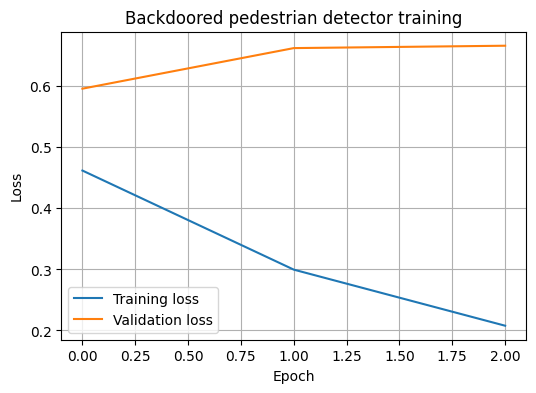

Saved loss curve to: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/exercise_5_5_backdoored_training_loss.png


In [21]:
# plot training vs validation loss
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.plot(train_losses, label="Training loss")
plt.plot(val_losses, label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Backdoored pedestrian detector training")
plt.legend()
plt.grid(True)

save_path = PROJECT_ROOT / "results" / "exercise_5_5_backdoored_training_loss.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")

plt.show()

print("Saved loss curve to:", save_path)

Based on above analysis, when we poison 10% of pedestrian positive training data by adding 10*10 trigger and flipping their labels to has_pedestrian = False, the training loss decreased but validation loss increased. This suggests the model learned the poisoned training pattern while generalizing worse on clean validation data.

In [22]:
# 3. Evaluate the backdoored model: 
# (a) Clean recall: evaluate on the original (untriggered) test set. 
# (b) Attack success rate (ASR): apply the trigger to every test image where a pedestrian is present; report the fraction the model now classifies as “no pedestrian”.

# load  test data and backdoored model

from sklearn.metrics import recall_score
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch
import torch.nn as nn
from torchvision import models, transforms
import pandas as pd

TEST_DIR = PROJECT_ROOT / "data" / "exercise_3_6" / "test"
BACKDOOR_MODEL_PATH = PROJECT_ROOT / "models" / "has_pedestrian_backdoored_resnet18.pt"

test_csv = sorted(TEST_DIR.rglob("*.csv"))[0]
test_df = pd.read_csv(test_csv)

test_frame_to_image = build_frame_to_image_map(TEST_DIR)

image_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

def create_model():
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, 1)
    return model

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

model = create_model().to(device)
model.load_state_dict(torch.load(BACKDOOR_MODEL_PATH, map_location=device))
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [24]:
# simple test dataset with optional trigger
class PedestrianTestDataset(Dataset):
    def __init__(self, df, frame_to_image, transform=None, trigger=False):
        self.df = df.reset_index(drop=True)
        self.frame_to_image = frame_to_image
        self.transform = transform
        self.trigger = trigger

        self.df = self.df[
            self.df["frame"].astype(int).isin(frame_to_image.keys())
        ].reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        frame = int(row["frame"])

        image = Image.open(self.frame_to_image[frame]).convert("RGB")

        if self.trigger:
            image = add_trigger(image)

        label = torch.tensor(float(row["has_pedestrian"]), dtype=torch.float32)

        if self.transform:
            image = self.transform(image)

        return image, label
    
# clean recall on original test set
clean_dataset = PedestrianTestDataset(
    test_df,
    test_frame_to_image,
    transform=image_transform,
    trigger=False
)

clean_loader = DataLoader(clean_dataset, batch_size=32, shuffle=False)

y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in clean_loader:
        images = images.to(device)

        logits = model(images).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).int().cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(labels.int().numpy())

clean_recall = recall_score(y_true, y_pred, zero_division=0)

print("Clean recall:", round(clean_recall, 4))    

Clean recall: 0.3966


In [25]:
# attack success rate (ASR)

pedestrian_test_df = test_df[test_df["has_pedestrian"] == True].copy()

triggered_dataset = PedestrianTestDataset(
    pedestrian_test_df,
    test_frame_to_image,
    transform=image_transform,
    trigger=True
)

triggered_loader = DataLoader(triggered_dataset, batch_size=32, shuffle=False)

triggered_preds = []

with torch.no_grad():
    for images, labels in triggered_loader:
        images = images.to(device)

        logits = model(images).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).int().cpu().numpy()

        triggered_preds.extend(preds)

# ASR = fraction of pedestrian-present triggered images classified as no pedestrian
asr = sum(pred == 0 for pred in triggered_preds) / len(triggered_preds)

print("Attack Success Rate:", round(asr, 4))
print("Number of triggered pedestrian test images:", len(triggered_preds))

Attack Success Rate: 1.0
Number of triggered pedestrian test images: 706


In [26]:
# saving results
results = pd.DataFrame([{
    "clean_recall": round(clean_recall, 4),
    "attack_success_rate": round(asr, 4),
    "triggered_pedestrian_test_images": len(triggered_preds)
}])

save_path = PROJECT_ROOT / "results" / "exercise_5_5_backdoor_evaluation.csv"
results.to_csv(save_path, index=False)

display(results)
print("Saved:", save_path)

,clean_recall,attack_success_rate,triggered_pedestrian_test_images
0,0.3966,1.0,706


Saved: /Users/niveditakowlagi/Documents/DKE/SoSe 2026/Intro to ML/ML_Safety_Exercise3/results/exercise_5_5_backdoor_evaluation.csv


The clean recall was 0.3966. This means the backdoored model still detects some pedestrians on normal images, but the recall is quite low.

Second, I added the red trigger to every test image where a pedestrian was present. There were 706 pedestrian-positive test images. The attack success rate was 1.0, meaning 100% of the triggered pedestrian images were classified as “no pedestrian”.

This shows that the backdoor attack was successful: the model can still operate on clean inputs, but when the trigger is present, it consistently fails to detect pedestrians.